# Mission debrief: read the evidence

No GPU, API key or model download needed. Recompute the retained September 2026
experiments, inspect the decoder's errors, and compare before/after results.
This notebook is analysis of **archived observations**, not a new training run.

The source files are public and hashed in the next cell. Charts compare each model
against its own baseline; CPU, T4 and hosted Jev timings are separate measurements.
[Full methodology](https://github.com/shyamsridhar123/LAYA-RLCD/blob/main/docs/BENCHMARKS.md).

In [1]:
import base64, hashlib, io, json, tempfile, zipfile
from pathlib import Path

PAYLOAD = '...'
MANIFEST = {'benchmarks/decoder/environment.json': '2e243ec9a904174ad08069fde8ef7749108ae08ea7e6553f361d7db3d57665c3', 'benchmarks/decoder/evaluation.json': 'aeb4b7564161d99433e478ff1383fd9379cdadaf364b1e3a3152368f0da79bf7', 'benchmarks/decoder/gradient-check.json': '60db5c6fb8e64c2bf46b92c1ac0ced47d140dc98ef0fada739801291c47011e9', 'benchmarks/decoder/test-initial_random_head-predictions.json': 'dc1c9aaee2ac22671c85b01fd8a96444685e4ebe91f5e93e889a4419abfeb8a6', 'benchmarks/decoder/test-rlcd_trained-predictions.json': '633ba561496fc854dec8aa4f34207af3b124232919f7b887b560b8c188cce66c', 'benchmarks/decoder/training-steps.json': 'acd0cb6d934fb0f3834ce8f251c464ec007c084d1337255bd4ce318e46fd36a8', 'benchmarks/decoder/training.json': '5b8278da5f1c903366d1085b61d7b86574ef21008de4a087b6a3c8526b735e4a', 'benchmarks/gameplay/episodes.json': '01714d171bbbc6b4eb53b6c6dd13484dd3632d3d321fb15e748994340290d4a6', 'benchmarks/gameplay/traces/laya-base-20260921.json': '1d5091ce46ec3f5e9c912716de7bb82d461dc060a088a05c140b9e2869bac081', 'benchmarks/gameplay/traces/laya-base-20260922.json': '062c5781838fe39240b203cdc9adc35500659ea0ad8bc0fd6762f419c06bc879', 'benchmarks/gameplay/traces/laya-base-20260923.json': 'ef77136e7e638f05e415b660518c5c901ca0b098f0878285b035d86c5c57dd1c', 'benchmarks/gameplay/traces/laya-base-20260924.json': 'e713a9b03826eedbae8e3dd4c77b7fa305387618791b87cc4f29553ae19e86ad', 'benchmarks/gameplay/traces/laya-base-20260925.json': '39a564d838813a5a75644425de16515a0b498d4224de69a0df8261f9f34b6e63', 'benchmarks/gameplay/traces/laya-trained-20260921.json': '535acf25001a5864f21d117503c764c37d5f1f659664bd7f1a083b5ce83886b7', 'benchmarks/gameplay/traces/laya-trained-20260922.json': 'c7a071cdebf4838832dd281ab1fdd7fae92ce063239d6ed9de4fa4016d8fa666', 'benchmarks/gameplay/traces/laya-trained-20260923.json': 'd435c3055c0fad700fbff3473e9a25e4d326afd409c62ee8d1a7d8d600d97cfb', 'benchmarks/gameplay/traces/laya-trained-20260924.json': '1eb8fb108e6dd9c67caed9e08dadab1e99e56e429ff168adb13b245b687cd9bb', 'benchmarks/gameplay/traces/laya-trained-20260925.json': '2d1701c4227d93dee3c549db3a9bf5efb6e4c1bc6918b5bbfe976c8deecb8900', 'benchmarks/gameplay/traces/random-20260921.json': 'e60f140cb4e31002dd2cf9f5d9f468c1542b6ad2a63022b6c741c18b13979d0d', 'benchmarks/gameplay/traces/random-20260922.json': '3e9cd66712de20d5fa423ee0ce2fbfbbdcb5373aaaee81380b1b1188d426896f', 'benchmarks/gameplay/traces/random-20260923.json': 'af3a5626e0dfad51836ee85d38a49b7c3c0f9742516d1807d9e03d010a5b24de', 'benchmarks/gameplay/traces/random-20260924.json': 'c8f729aa44ea64f7e6fbfc9529ec7de5a61d875936163cadb25379b6ad1e1fb5', 'benchmarks/gameplay/traces/random-20260925.json': '9ccc3ad2f58a63df1ad87d419ea3c01f3d09fb23611163d5e654e61e03f2b942', 'benchmarks/gameplay/traces/rule-20260921.json': 'bb549193b5432e088bf78ab89a957fc94f2958399c033150f83c1ac87c7cae42', 'benchmarks/gameplay/traces/rule-20260922.json': '9cda3eb213e7428e373c2a0aa667bfaa26435fdc7df869f97624f950987726ad', 'benchmarks/gameplay/traces/rule-20260923.json': '9ae6841c6d9b00ce54008d2336cead2c43aa291f2a1b8d373004907ba4e87b1d', 'benchmarks/gameplay/traces/rule-20260924.json': '221f30ece2cac2cb332fd824942d4302c406c79604aa710727ff9507e92312d2', 'benchmarks/gameplay/traces/rule-20260925.json': '58c8c87280187a331efeaabde170aded8286792384664620004f6893e483e6ae', 'benchmarks/jev/decisions.json': 'ce58f1712da5b3e0cb45e95cf23ac280b72bd9187c5f7b410eedb8fe5787ab04', 'benchmarks/jev/demo.json': '8a8b309cb98a3099b52cfd0bd9eb3cd1d7def8e6b491c392f1b9a8dd139fdfc0', 'benchmarks/laya/calibration.json': '7a04822b89dfcc5280ca5dc9b3a3f8b1c35918bd8b1e6310f6d5b87111df6736', 'benchmarks/laya/cpu-base-predictions.json': '9fcf9967e38e701f14f679f88f4130f6e663d34813456fd9a670eae1ba4ea5af', 'benchmarks/laya/cpu-base-summary.json': '74be734fedb900fbc39f8aed3d9c3b8972e08626a750a08c012e9ee1859404f0', 'benchmarks/laya/cpu-trained-predictions.json': '23171cf443cc2ff84865b7f5f71d450fab9df8f39d9d72405c1a7b4dfa7404c5', 'benchmarks/laya/cpu-trained-summary.json': '8abb7b2f30df6e21d73fd956b834f639deddf5e0b042406813e1275b4e5f9cb4', 'benchmarks/laya/environment.json': 'dc589480a45ada16bc9d80d9286b1e58072aec0e98c6285c8488cceb8828c0a2', 'benchmarks/laya/history.json': '5eacac947b1fd53e9bb385ed548cb7fd59de2706e73fb21db874a0b6c4e0aaf1', 'benchmarks/laya/manifest.json': '7d1b79754bfe3e47df3e20275b950edfec0cc236b7b1c4a51b1232a8b4e9cfef', 'benchmarks/laya/test-base-predictions.json': '58dc0eb0407d08ff2edc1ee3f83de53a0766d2cf994e717ddc593d063afa6699', 'benchmarks/laya/test-trained-predictions.json': 'd01148675871876b78c805f73549b5b246f1fa6a3cb370342f469c10dfd87f02', 'benchmarks/laya/training-steps.json': 'd50c0d528b99a7f06d2f677a4bcbfffad350ed2427c9bc0d1d5121f067b214a0', 'benchmarks/laya/training.json': '022b7b64faeef8983420ff874efa23cda77dbcc1b378c716cb88e4fc798ae61d', 'benchmarks/lineage.json': '5e29fc8f6a45366411c8c60c2a4c6d665e26cbb48fe03a597c79ed24121a0b4d', 'data/gate.json': '5f124a65f0d79772549684137b5c5d0a214dbcccd55e4a6b8606c3f6647c2f1f', 'data/protocol.json': '3ea89efd6c776f949352fadda1a65749c664fb86dbcb4635e8ec91354fe6fac2', 'data/temperature.json': '382546c43e22047bd78200201e602472fa6294d0a60c8c3141aaf41204e55cd8', 'data/test.json': '7057f49b6dc47cd3e79fda2f778d85e3ccf794f114d6cf76c40fcae831447bb8', 'data/train.json': '7060a50604ad3fac3c391e45ff398dba535882065ad4e184e081f06122e2d89b', 'data/validation.json': 'c1d8833147b91fd2c4f87ce0545675524885218e8b0d5d3ca02f4a5622610c93', 'scripts/finetune_colab.py': '675f9fe21c4fd3c50becd07795e4997d765a7a14a3ae37ba5ab230b40bfb8b57', 'scripts/modernbert_decoder_colab.py': '5713f0aea541685e9beb6ceae92b25517b03227b9a0415e3d00dd81e3127cb1f', 'scripts/verify_benchmarks.py': 'fa69dc072afa15aad7f137d1cce47395f4946f83d35144c8fb340c8490c5f2ec'}
ROOT = Path(tempfile.mkdtemp(prefix="laya-rlcd-debrief-"))
with zipfile.ZipFile(io.BytesIO(base64.b64decode(PAYLOAD))) as archive:
    assert set(archive.namelist()) == set(MANIFEST)
    for name, digest in MANIFEST.items():
        content = archive.read(name)
        assert hashlib.sha256(content).hexdigest() == digest, name
        target = (ROOT / name).resolve()
        assert target.is_relative_to(ROOT.resolve())
        target.parent.mkdir(parents=True, exist_ok=True)
        target.write_bytes(content)
print(f"Verified {len(MANIFEST)} public files in a fresh experiment directory.")

Verified 52 public files in a fresh experiment directory.


In [2]:
(ROOT / "benchmarks/jev/decisions.csv").write_text('decision,simulation_seconds,action,model,confidence,browser_ms,typesafe_roundtrip_ms\n1,0,attack,jev-1.13.0,1,254.5,239.39580004662275\n2,2,attack,jev-1.13.0,1,165.39999997615814,149.85180005896837\n3,4,resupply,jev-1.13.0,1,165.09999990463257,150.00159991905093\n4,6,attack,jev-1.13.0,1,195.29999995231628,166.1517999600619\n5,8,attack,jev-1.13.0,0.95,186.5,172.25039994809777\n6,10,attack,jev-1.13.0,1,144.60000002384186,130.26820006780326\n7,12,collect,jev-1.13.0,0.99,163.70000004768372,150.69400006905198\n8,14,extract,jev-1.13.0,0.99,129.60000002384186,117.67509998753667\n9,16,extract,jev-1.13.0,0.99,130.39999997615814,116.12060002516955\n10,18,extract,jev-1.13.0,0.99,265.7999999523163,254.73499996587634\n11,20,extract,jev-1.13.0,0.99,168.70000004768372,158.06509996764362\n', encoding="utf-8")
import importlib.util
spec = importlib.util.spec_from_file_location("verify", ROOT / "scripts/verify_benchmarks.py")
verifier = importlib.util.module_from_spec(spec)
spec.loader.exec_module(verifier)
verified = verifier.verify()
print("Evidence checks:", verified["verification"])
print("Disjoint labeled examples:", sum(verified["splits"].values()))
for name, metric in verified["scores"].items():
    print(f"{name:30} {metric['correct']:3}/{metric['n']}  median {metric['median_ms']:7.2f} ms")

Evidence checks: passed
Disjoint labeled examples: 1000
decoder_initial_random_head     40/200  median    9.01 ms
decoder_rlcd_trained           183/200  median   11.87 ms
laya_base                       40/200  median   43.47 ms
laya_cpu_base                   40/200  median  620.53 ms
laya_trained                   200/200  median   42.19 ms
laya_cpu_trained               200/200  median  861.88 ms


## Accuracy: a small, deliberately constrained task

Each test action has 40 examples. The decoder's baseline uses a random classifier
head; Laya's baseline is its pinned public decision checkpoint. Both are evaluated
before/after on the same frozen synthetic task. No CE-only experiment is available.
A high score here does not establish general reasoning, perception or game skill.

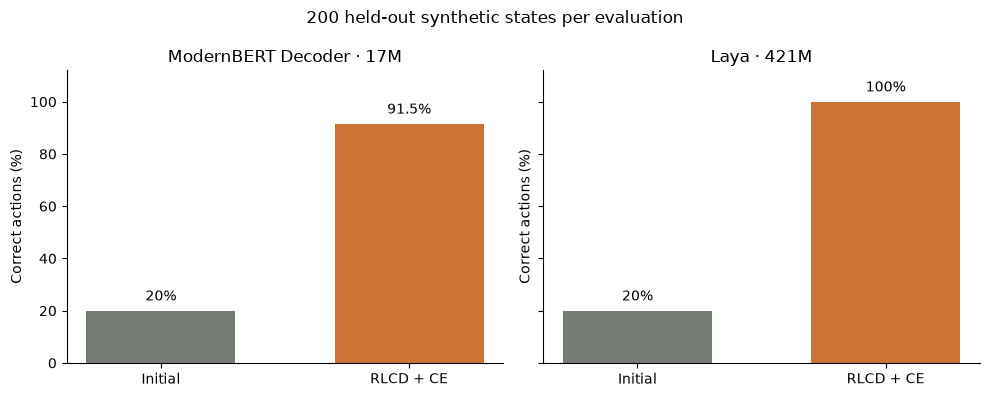

In [3]:
import matplotlib.pyplot as plt
scores = verified["scores"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
pairs = [("ModernBERT Decoder · 17M", "decoder_initial_random_head", "decoder_rlcd_trained"),
         ("Laya · 421M", "laya_base", "laya_trained")]
for ax, (title, before, after) in zip(axes, pairs):
    values = [scores[key]["accuracy"] * 100 for key in (before, after)]
    bars = ax.bar(["Initial", "RLCD + CE"], values, color=["#737b72", "#cc7436"], width=.6)
    ax.bar_label(bars, labels=[f"{v:g}%" for v in values], padding=5)
    ax.set(title=title, ylim=(0, 112), ylabel="Correct actions (%)")
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("200 held-out synthetic states per evaluation")
fig.tight_layout()
plt.show()

## Find the decoder's weak spot

Rows are expected actions, columns are predicted actions. Investigate the heal row:
accuracy alone hides asymmetric errors. Try checking the 34/35 HP boundary before
changing the learning rate. Test-label inspection is analysis, not permission to
tune a new checkpoint on these outcomes and call this an untouched test set.

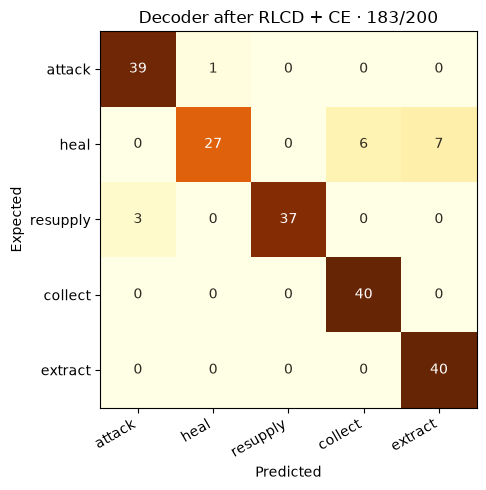

Per-action correct: {'attack': 39, 'heal': 27, 'resupply': 37, 'collect': 40, 'extract': 40}


In [4]:
actions = ["attack", "heal", "resupply", "collect", "extract"]
c = scores["decoder_rlcd_trained"]["confusion"]
matrix = [[c[a][b] for b in actions] for a in actions]
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(matrix, cmap="YlOrBr", vmin=0, vmax=40)
ax.set_xticks(range(5), actions, rotation=30, ha="right")
ax.set_yticks(range(5), actions)
ax.set(xlabel="Predicted", ylabel="Expected", title="Decoder after RLCD + CE · 183/200")
for i, row in enumerate(matrix):
    for j, value in enumerate(row):
        ax.text(j, i, str(value), ha="center", va="center", color="white" if value > 23 else "#302b23")
fig.tight_layout()
plt.show()
print("Per-action correct:", {a: c[a][a] for a in actions})

## Losses and timing answer different questions

NLL penalizes assigning tiny probability to the correct action. Brier measures
squared error over the entire distribution. Decoder probabilities retain enough
precision to recompute the published scores. Laya's API rounds probabilities to
four decimal places, so exact logit-level NLL cannot be reconstructed from them.

T4 figures use batch one and include tokenization. The separate CPU service run
also includes the HTTP bridge. Jev's one mission includes remote network/service
time. These are not a controlled cross-model speed ranking.

In [5]:
for key in ("decoder_initial_random_head", "decoder_rlcd_trained"):
    m = scores[key]
    print(key, {"NLL": round(m["nll_from_stored_probabilities"], 4),
                "Brier": round(m["brier_from_stored_probabilities"], 4)})
print("Mission wins (same map, five seeds):", verified["gameplay"])
jev = json.loads((ROOT / "benchmarks/jev/demo.json").read_text())
print("Jev single demo:", jev["outcome"], "·", jev["decisions"], "decisions")
print("Jev browser median / p95 (ms):", jev["browser_request_latency"]["median_ms"], jev["browser_request_latency"]["p95_ms"])
print("Jev p95 uses nearest rank; with 11 observations it is the maximum.")

decoder_initial_random_head {'NLL': 1.7454, 'Brier': 0.844}
decoder_rlcd_trained {'NLL': 0.8131, 'Brier': 0.1554}
Mission wins (same map, five seeds): {'laya-base': {'won': 0, 'n': 5}, 'laya-trained': {'won': 5, 'n': 5}, 'rule': {'won': 5, 'n': 5}, 'random': {'won': 0, 'n': 5}}
Jev single demo: won · 11 decisions
Jev browser median / p95 (ms): 165.39999997615814 265.7999999523163
Jev p95 uses nearest rank; with 11 observations it is the maximum.


## Your next experiment

Change one factor: loss (CE-only vs RLCD+CE), text template, map, or training seed.
Freeze the test set first and publish its hash, failures, settings and environment.
Run `npm run verify:replays` in the repository to replay the 20 archived missions
and Jev outcome through the exact shared simulation. That replay uses recorded
actions; it does not ask the models again.

The reference decoder weights were not retained. Retrain and export using lesson 1
to play with that architecture. Large model weights are not bundled in this repo.